In [ ]:
# This project analyzes retail sales data to identify key factors affecting profitability and provide actionable business recommendations.

In [5]:
import pandas as pd

df = pd.read_csv("sample superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [6]:
# Data inspection
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [7]:
#Data cleaning

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df = df.drop_duplicates()

In [10]:
#visualization


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

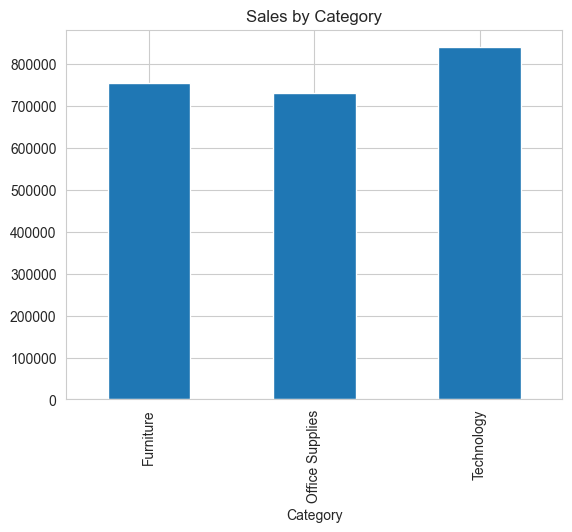

Insight: Technology category generates the highest sales, indicating strong demand compared to other categories.


In [41]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', title="Sales by Category")
plt.show()


print("Insight: Technology category generates the highest sales, indicating strong demand compared to other categories.")


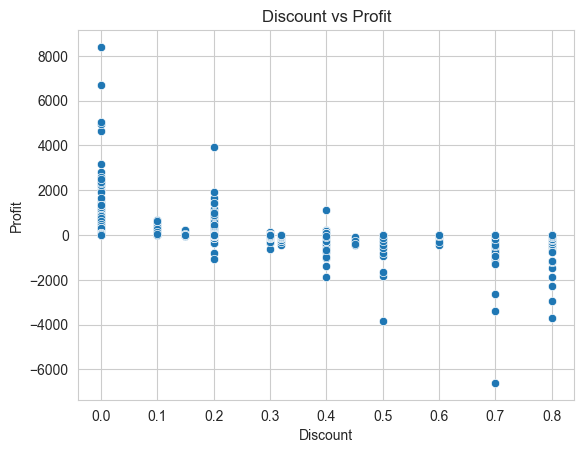

Insight: Higher discounts are strongly associated with negative profits, showing that aggressive discounting harms profitability.


In [85]:
#DISCOUNT VS PROFIT GRAPH

sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()


print("Insight: Higher discounts are strongly associated with negative profits, showing that aggressive discounting harms profitability.")





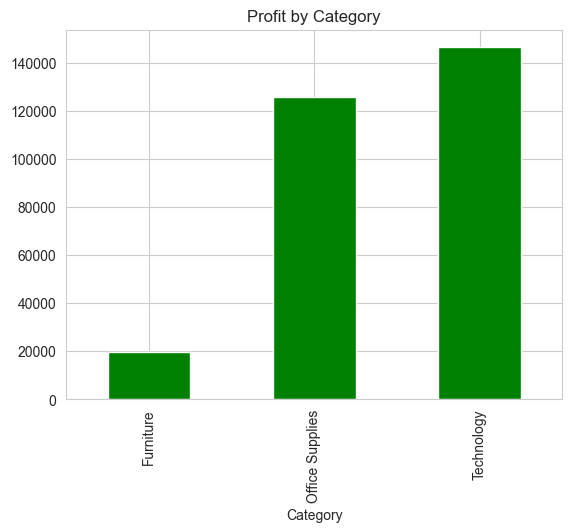

Insight: Technology contributes the highest profit, while some categories show lower profitability despite decent sales.


In [86]:
category_profit = df.groupby('Category')['Profit'].sum()
category_profit.plot(kind='bar', color='green', title="Profit by Category")
plt.show()

print("Insight: Technology contributes the highest profit, while some categories show lower profitability despite decent sales.")

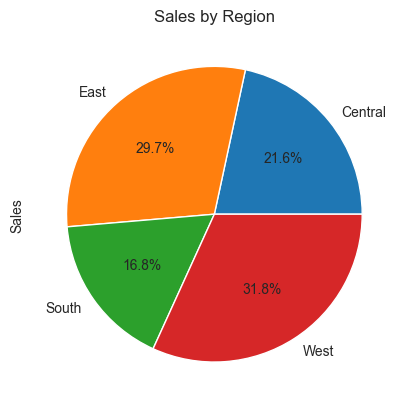

Insight: Sales are concentrated in specific regions, showing uneven market distribution across regions.


In [87]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='pie', autopct='%1.1f%%', title="Sales by Region")
plt.show()

print("Insight: Sales are concentrated in specific regions, showing uneven market distribution across regions.")

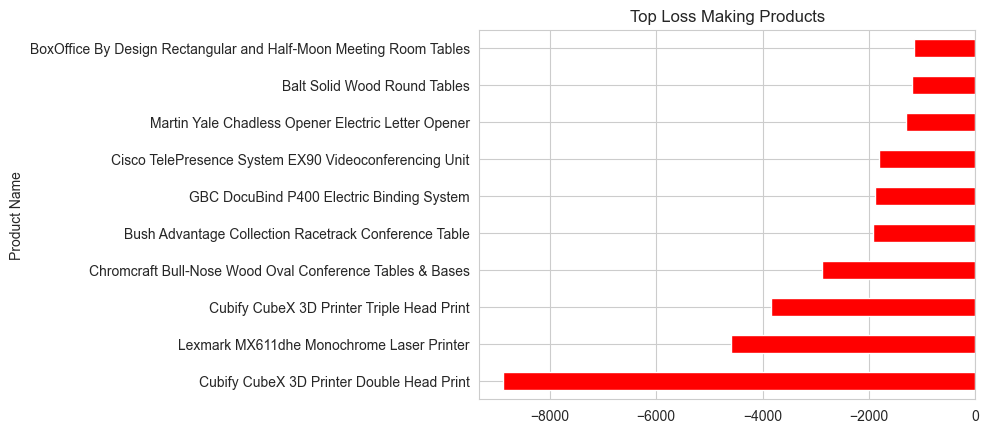

In [88]:
loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
loss_products.plot(kind='barh', color='red', title="Top Loss Making Products")
plt.show()

In [89]:
#KPI metrics

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_discount = df['Discount'].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Average Discount:", avg_discount)

Total Sales: 2326534.3543
Total Profit: 292296.8146
Average Discount: 0.15538453992544635


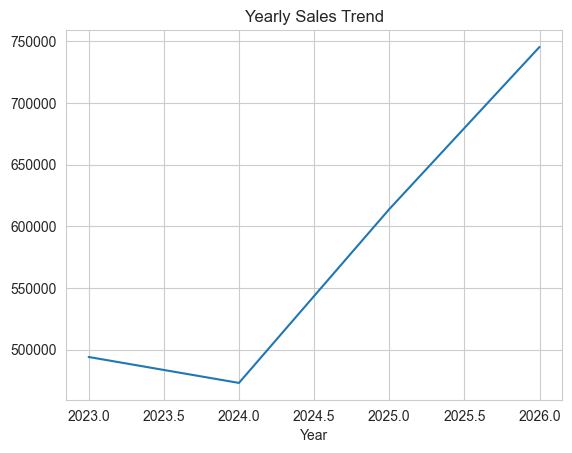

In [ ]:
# Time based analysis

df['Year'] = df['Order Date'].dt.year
df.groupby('Year')['Sales'].sum().plot()
plt.title("Yearly Sales Trend")
plt.show()

In [91]:
df.rename(columns={'State/Province': 'State'}, inplace=True)

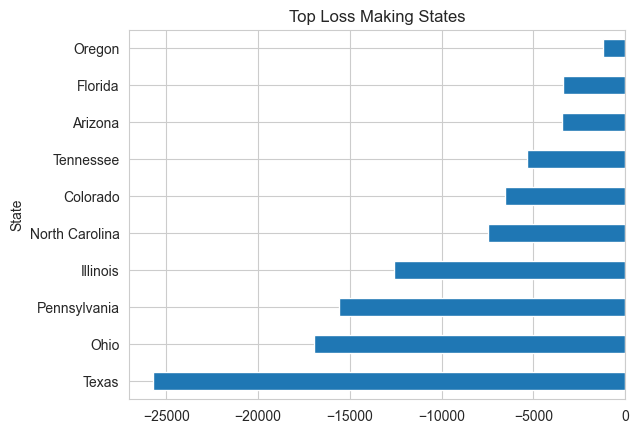

Insight: States like Texas and Ohio contribute significantly to overall losses, indicating inefficient pricing or high discounting.


In [98]:
#STATE LEVEL ANALYSIS
state_profit = df.groupby('State')['Profit'].sum().sort_values()

state_profit.head(10).plot(kind='barh', title="Top Loss Making States")
plt.show()

print("Insight: States like Texas and Ohio contribute significantly to overall losses, indicating inefficient pricing or high discounting.")

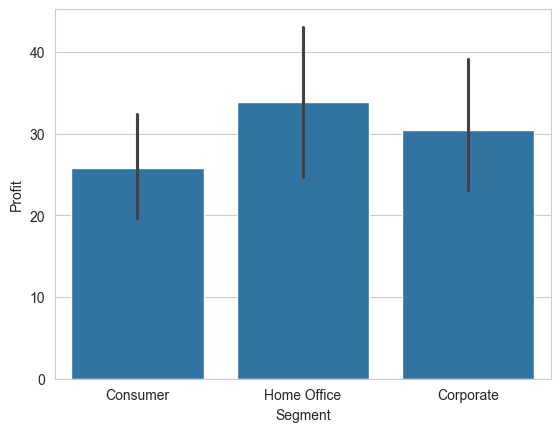

In [99]:
#segment plus category analysis
sns.barplot(x='Segment', y='Profit', data=df)
plt.show()

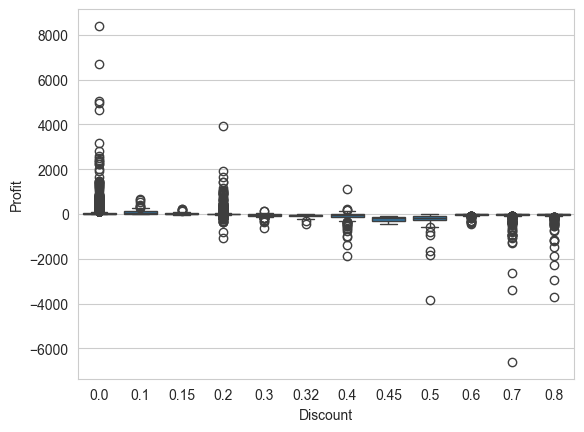

In [100]:
#discount impact
sns.boxplot(x='Discount', y='Profit', data=df)
plt.show()

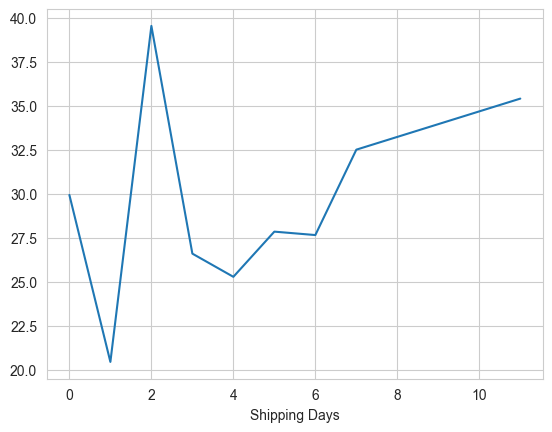

Insight: Longer shipping durations may increase operational costs and impact customer satisfaction.


In [104]:
# Shipping efficiency
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df.groupby('Shipping Days')['Profit'].mean().plot()
plt.show()

print("Insight: Longer shipping durations may increase operational costs and impact customer satisfaction.")

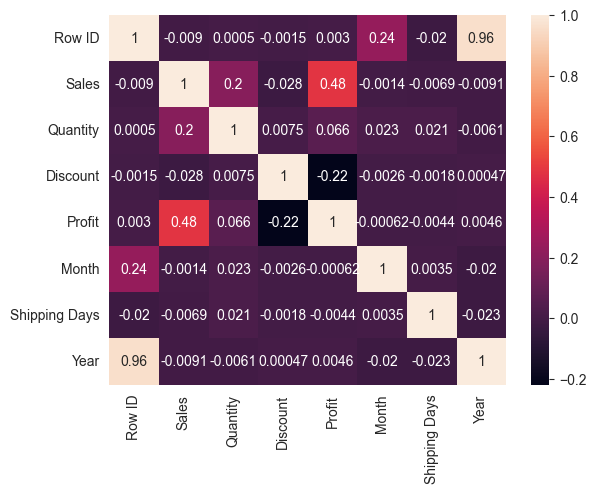

Insight: Discount has a negative correlation with profit, confirming that higher discounts reduce profitability.


In [107]:
#Correlation analysis
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

print("Insight: Discount has a negative correlation with profit, confirming that higher discounts reduce profitability.")

In [108]:
# =========================
# FINAL INSIGHTS
# =========================

print("Key Insight: High discounting is the primary cause of losses.")
print("Key Insight: Certain states underperform significantly.")

# =========================
# RECOMMENDATIONS
# =========================

print("Recommendation: Optimize discount strategy.")
print("Recommendation: Focus on high-performing regions.")

Key Insight: High discounting is the primary cause of losses.
Key Insight: Certain states underperform significantly.
Recommendation: Optimize discount strategy.
Recommendation: Focus on high-performing regions.
